In [1]:
%run utilities_general.ipynb
%run utilities_DIRKs_and_PIRKs.ipynb 
load_standard_packages()
change_wordir()
from tqdm import tqdm

import itertools as it
import seaborn as sns
import numbers

C:\Users\andre\AppData\Local\Temp\ipykernel_11472\2093705289.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [2]:
analysis = "sensitivity"

colors, colours = colourblind_palette("own")

#model = "cyclic_2021"
#model = "cyclic_2021_ODE"
#model = "new_PSI"
#model = "new_PSII"
#model = "new_b6f"
model = "with_dpsi"
#model = "latest_dev"

m = load_model(model)


succesfully loaded with_dpsi :D


In [3]:
# I like to have light as a derived variable
m.add_algebraic_module(module_name = "Light",
    function = lambda X, PFD: PFD, # X is not used
    compounds = ["PQ"], derived_compounds = ["L"], parameters = ['pfd'])

In [4]:
y0 = get_stst_y0(m, pfd =70) # pfd = 1200

In [5]:
def perturbe(parameters, perturbation=0.01):
    perturbed_params = {}
    for key, value in parameters.items():
        if not isinstance(value, numbers.Real) or isinstance(value, bool): continue
        # we want the first value to always be the lowest!
        perturbation_order = perturbation * np.array([-1, 0, 1]) * np.sign(value) # returns [-perturbation,0, perturbation], and flippes this array if x is negative

        perturbed_params[key] = value * (1 + np.array(perturbation_order))  # perturb by ±1%
    return perturbed_params

# m.get_all_parameters()

# perturbed_parameters = perturbe(m.get_all_parameters())
# perturbed_parameters

In [6]:
def sensitivity_analysis(m, y0, protocols: dict, parameters, perturbation=0.01, debug = False):

    original_parameters = m.get_parameters()
    # Store the original parameters to restore them later

    results = pd.DataFrame()

    perturbed = perturbe(parameters, perturbation)
    for param, values in tqdm(perturbed.items()):
        x_minus, x, x_plus = values
        for protocol_name, protocol_info in protocols.items():
            protocol, analysis_script, kwargs_protocol, kwargs_analysis = protocol_info
            readouts = {}
            for low_or_up, param_value in zip(["x_minus", "x", "x_plus"], [x_minus, x, x_plus]):
                s = Simulator(m)
                s.initialise(y0)
                careful_change_parameter(s, param, param_value, original_parameters)
                c, _ = protocol(s, **kwargs_protocol)
                readouts[low_or_up] = analysis_script(c, **kwargs_analysis)
            for variable in readouts["x_minus"].keys():
                y_plus = readouts["x_plus"][variable]
                y_minus = readouts["x_minus"][variable]
                y = readouts["x"][variable]

                debug_this("param", param, debug)
                debug_this("variable", variable, debug)
                debug_this("y_plus", y_plus, debug)
                debug_this("y_minus", y_minus, debug)
                debug_this("2*epsilon", x_plus - x_minus, debug)
                debug_this("x_plus", x_plus, debug)
                debug_this("x_minus", x_minus, debug)

                #check if y is close to zero, if so, skip this variable
                if np.isclose(y, 0):
                    responsiveness = np.nan
                elif np.isclose(y_plus, y_minus, rtol=1e-5, atol=1e-8):
                    responsiveness = 0
                else:
                    df_dx = (y_plus - y_minus) / (x_plus - x_minus)  # finite difference approximation
                    # debug_this("df_dx", df_dx)
                    responsiveness = abs(x / y) * df_dx
                
                results.loc[param, variable] = responsiveness

    # restore original parameters
    m.update_parameters(original_parameters)  # Reset to original parameters
    s.update_parameters(original_parameters)  # Reset to original parameters in simulator
    return results

# Create a custom normalization for the heatmap based on signed log10
def signed_doublelog2(x):
    return np.sign(x) * np.log2(np.log2(np.abs(x) + 1)+1)

In [7]:
# Example protocols dictionary with kwargs for DIRK

pre_relax_time = 0.01
pfd_illum = 100
relax_time = 0.04
relax_pfd = 0
post_relax_time = 0.01

DIRK_protocol = [(pre_relax_time, pfd_illum),
            (relax_time, relax_pfd),
            (post_relax_time, pfd_illum)
            ]


protocols = {#simulation_function, analysis_fucntion, kwargs_to_simulation, kwargs_to_analysis_function
    "DIRK": [apply_protocol,
             analyse_DIRK_from_simulation,
             {"protocol": DIRK_protocol, "use_tqdm": False, "shift_time": False, "output_in_ms" : False},
             {"protocol": DIRK_protocol, "input_is_in_ms": False, "visualize": ""} # no visualization bc would be hundreds!
    ]
}

parameters = m.get_parameters()
# parameters = {param: m.get_parameter(param) for param in ["max_b6f", "kPCox",
#                                                         "pHstroma", "pKreg"
#                                                         ]}

parameters = { "pHstroma": parameters["pHstroma"] }

pertubation = 1e-3

#epsilons = [0.05, 0.04, 0.03, 0.02, 0.01]
#for pertubation in epsilons: # for pertubation >= 0.2 modelbase crashed

100%|██████████| 1/1 [00:11<00:00, 11.39s/it]


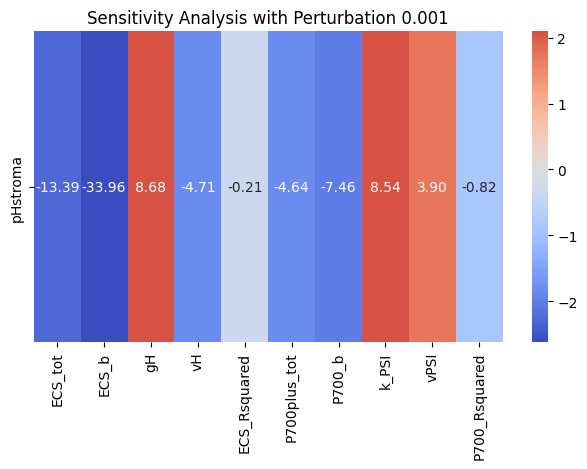

In [10]:
results = []

result = sensitivity_analysis(m, y0, protocols, parameters, perturbation=pertubation, debug = False)
results.append(result)

log_result = result.applymap(signed_doublelog2)

sns.heatmap(log_result, annot=result, cmap="coolwarm", fmt=".2f", center=0)
plt.title(f"Sensitivity Analysis with Perturbation {pertubation}")
plt.tight_layout()
plt.show()

In [ ]:
#pfd_illum = 750

In [8]:
results = checkpoint("results", f"{model}/{analysis}", f"DIRK_all_parameters_{pfd_illum}pfd", overwrite=True)

Loaded: pickles/with_dpsi/sensitivity\DIRK_all_parameters_100pfd.joblib


In [23]:
# del results

relevant_parameters = Index(['convf', 'PSIItot', 'PSItot', 'PQtot', 'PCtot', 'Fdtot', 'NADPtot',
       'APtot', 'k2', 'kStt7', 'kPph1', 'KM_ST', 'n_ST', 'staticAntI',
       'kATPsynth', 'Pi_mol', 'DeltaG0_ATP', 'HPR', 'pHstroma', 'b6f_content',
       'max_b6f', 'pKreg', 'kPCox', 'kcatFNR', 'kcyc', 'EFNR', 'kphSatLHC',
       'kphSat', 'E0_QA', 'E0_PQ', 'E0_PC', 'E0_P700', 'E0_Fd', 'F', 'R', 'T',
       'Cp', 'Pext', 'V9_base', 'Vst_base', 'Vmax_efflux', 'q2', 'q3', 'q7',
       'q8', 'q12', 'q14', 'Km131', 'Kpga', 'Kpi', 'Kpxt', 'Kast1', 'k',
       'k_ex_atp', 'k_ex_nadph', 'k_fd_tr_reductase', 'k_e_cbb_relaxation'],
      dtype='object')


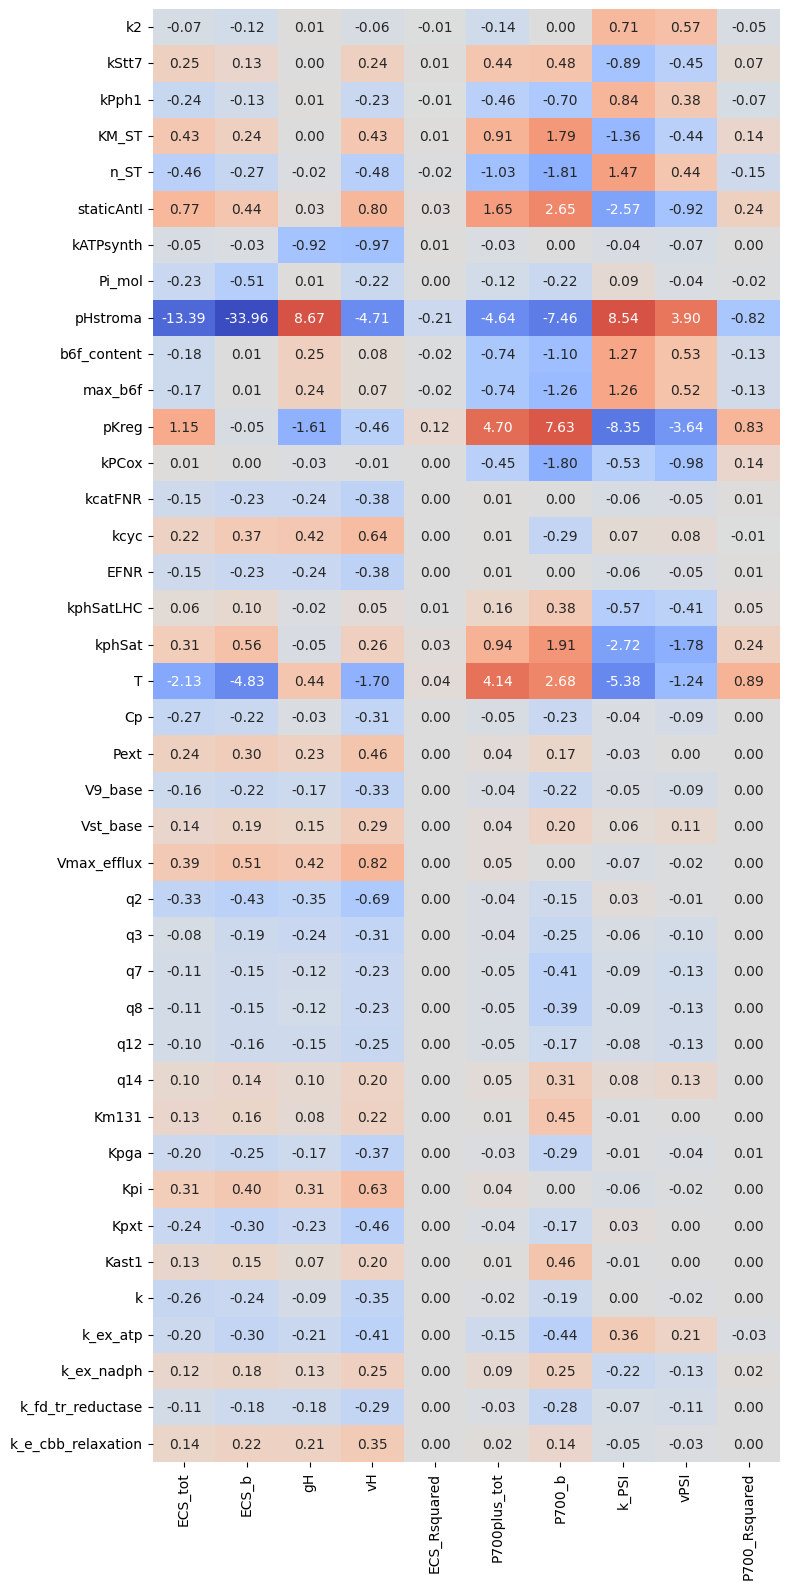

In [9]:
result = results[0]

res = result[result.abs().mean(axis=1) >= 0.1]

print(f"relevant_parameters = {res.index}")

res = res.drop(["convf", "PSIItot", "PSItot", "PQtot", "PCtot", "thioredoxin_tot",
                "Fdtot", "NADPtot", "APtot", "Psbstot", "e_cbb_tot", 
                "DeltaG0_ATP", "F", "R", 
                "E0_QA", "E0_Fd", "E0_PC", "E0_PQ", "E0_P700", "E0_FA", "HPR"], errors = "ignore")
# res = res.drop(["F", "R"], errors = "ignore")

log_result = res.applymap(signed_doublelog2)

# 1. create fig and ax
fig, ax = plt.subplots(
    figsize=(log_result.shape[1]*0.8, log_result.shape[0]*0.4)
)

# 2. plot into that ax
sns.heatmap(
    log_result,
    annot=res,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    cbar=False,
    ax=ax
)

#ax.set_title(f"Sensitivity analysis at AL = {pfd_illum}")
fig.tight_layout()

In [25]:
save_fig(fig, model, analysis, f"complete_with_AL{pfd_illum}")

saved figure to figures/with_dpsi/sensitivity/complete_with_AL100.png


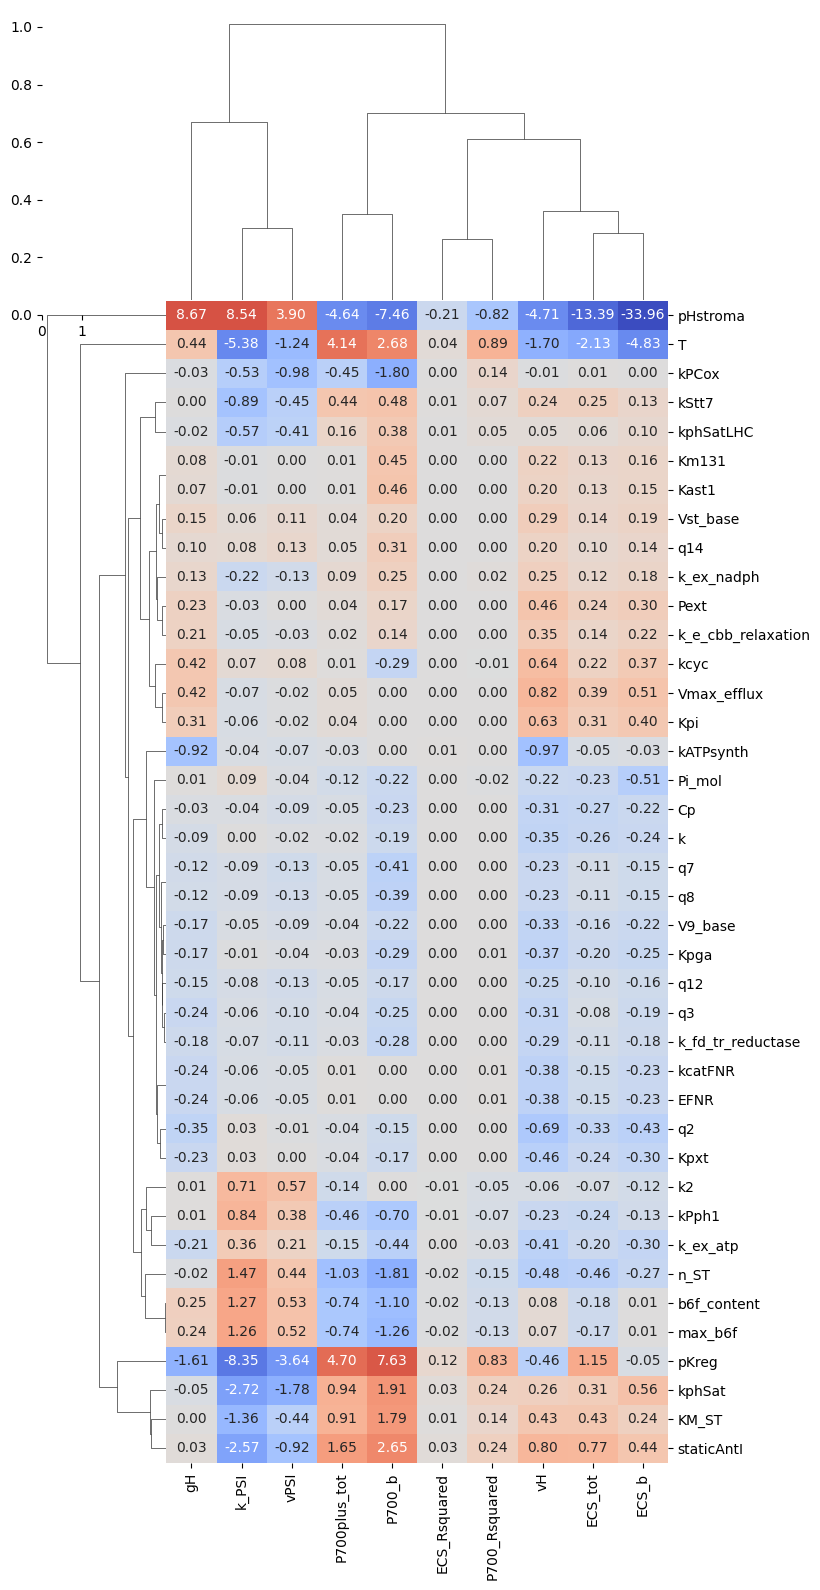

In [10]:
sns.clustermap(
    log_result, 
    annot=res,
    cmap="coolwarm", 
    center=0, 
    fmt=".2f",
    row_cluster=True, 
    col_cluster=True,
    figsize=(log_result.shape[1]*0.8, log_result.shape[0]*0.4),
    cbar=False
)
#plt.suptitle(f"Sensitivity Analysis with Perturbation {pertubation}")
plt.show()